In [1]:
import sys
from pathlib import Path

# notebooks → deep
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)

import numpy as np

from core.utils import load_run_data

import jax.numpy as jnp
import matplotlib.pyplot as plt
from notebooks.mail import email_pdf
import time


PROJECT_ROOT: /usr/project/xtmp/ds541/td-avar-explore/deep
📧 Email functions ready!
Try: test_email() first, then email_pdf_simple()


In [2]:
ep_config, ep_metrics = load_run_data("3_26_oracle/episodic_long_mem", "FourRooms-misc",)
cont_config, cont_metrics = load_run_data("3_26_oracle/continuing_long_mem", "FourRooms-misc",)
abs_config, abs_metrics = load_run_data("3_26_oracle/absorbing_long_mem", "FourRooms-misc",)


📁 Found ../figures/all_envs_abs_oracle.pdf (30.0 KB)
📤 Sending to ds541@cs.duke.edu using sendmail...
✅ Email sent successfully with attachment!
📧 Check your inbox at ds541@cs.duke.edu


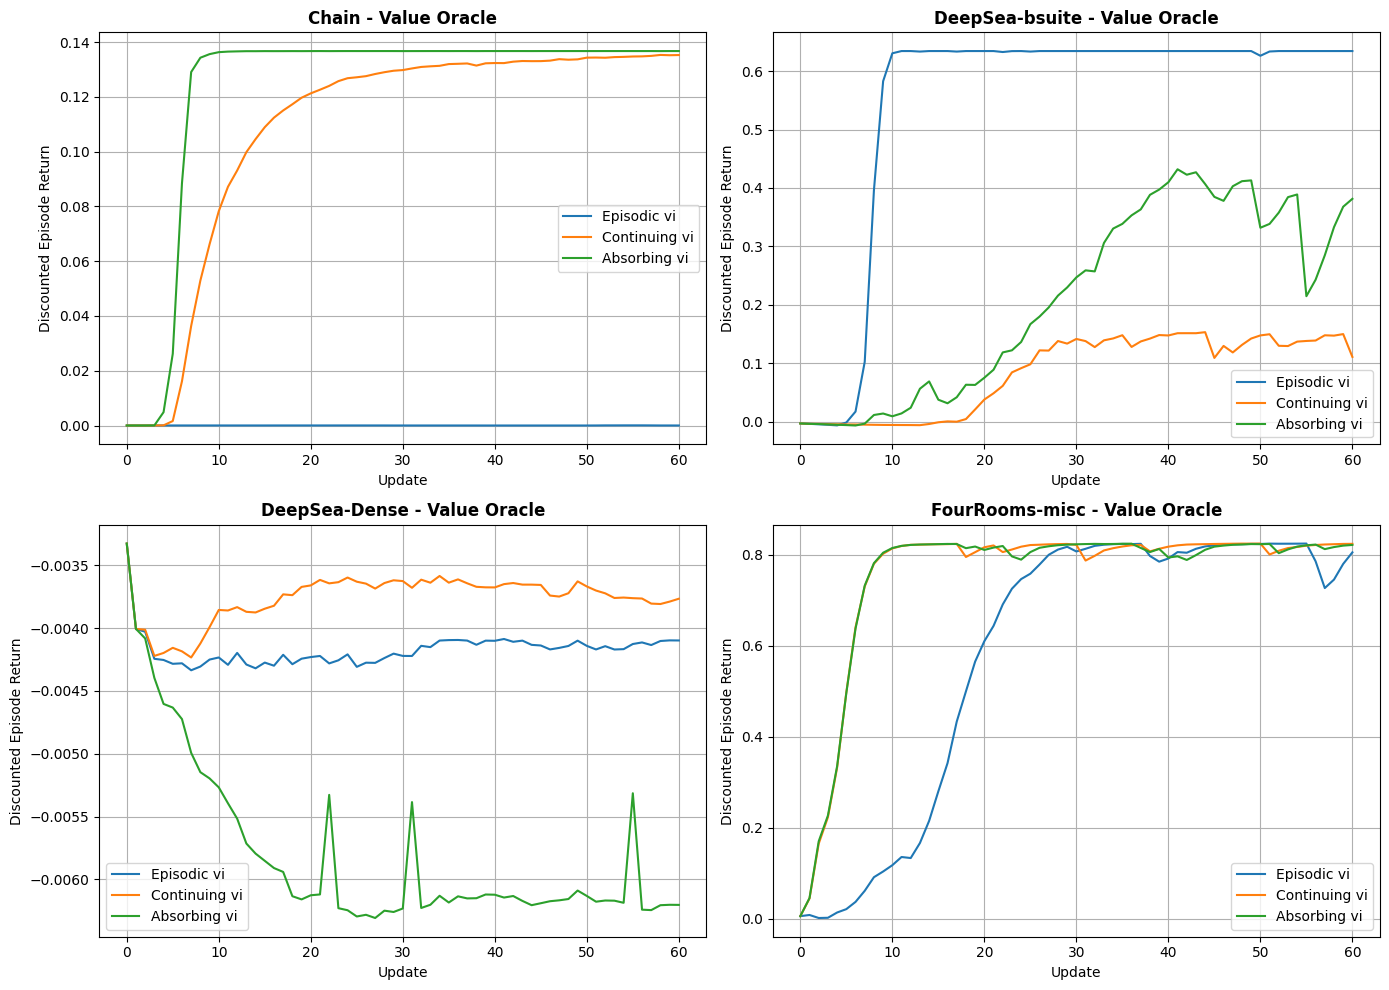

In [3]:
import matplotlib.pyplot as plt



# 1. Define the environments and run variants
environments = [
    "Chain", 
    "DeepSea-bsuite", 
    "DeepSea-Dense", 
    "FourRooms-misc"
]

run_variants = {
    'Episodic vi': '3_26_oracle/episodic_long_mem',
    'Continuing vi': '3_26_oracle/continuing_long_mem',
    'Absorbing vi': '3_26_oracle/absorbing_long_mem'
}

# 2. Set up a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten() # Flatten to 1D array for easy iteration

# 3. Loop through environments and plot on their respective axes
for i, env in enumerate(environments):
    ax = axes[i]
    
    for label, base_path in run_variants.items():
        # Load the data
        config, metrics = load_run_data(base_path, env)
        
        # Extract the metric and average over seeds (assuming dim 0 is seeds)
        # Note: Adjust slicing if your metric array has extra dimensions
        returns = metrics['returned_discounted_episode_returns'].mean(0)
        
        ax.plot(returns, label=label)
        
    # Format each subplot
    ax.set_title(f'{env} - Value Oracle', fontsize=12, fontweight='bold')
    ax.set_ylabel('Discounted Episode Return')
    ax.set_xlabel('Update')
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.savefig('../figures/all_envs_abs_oracle.pdf')
email_pdf('../figures/all_envs_abs_oracle.pdf')
plt.show()


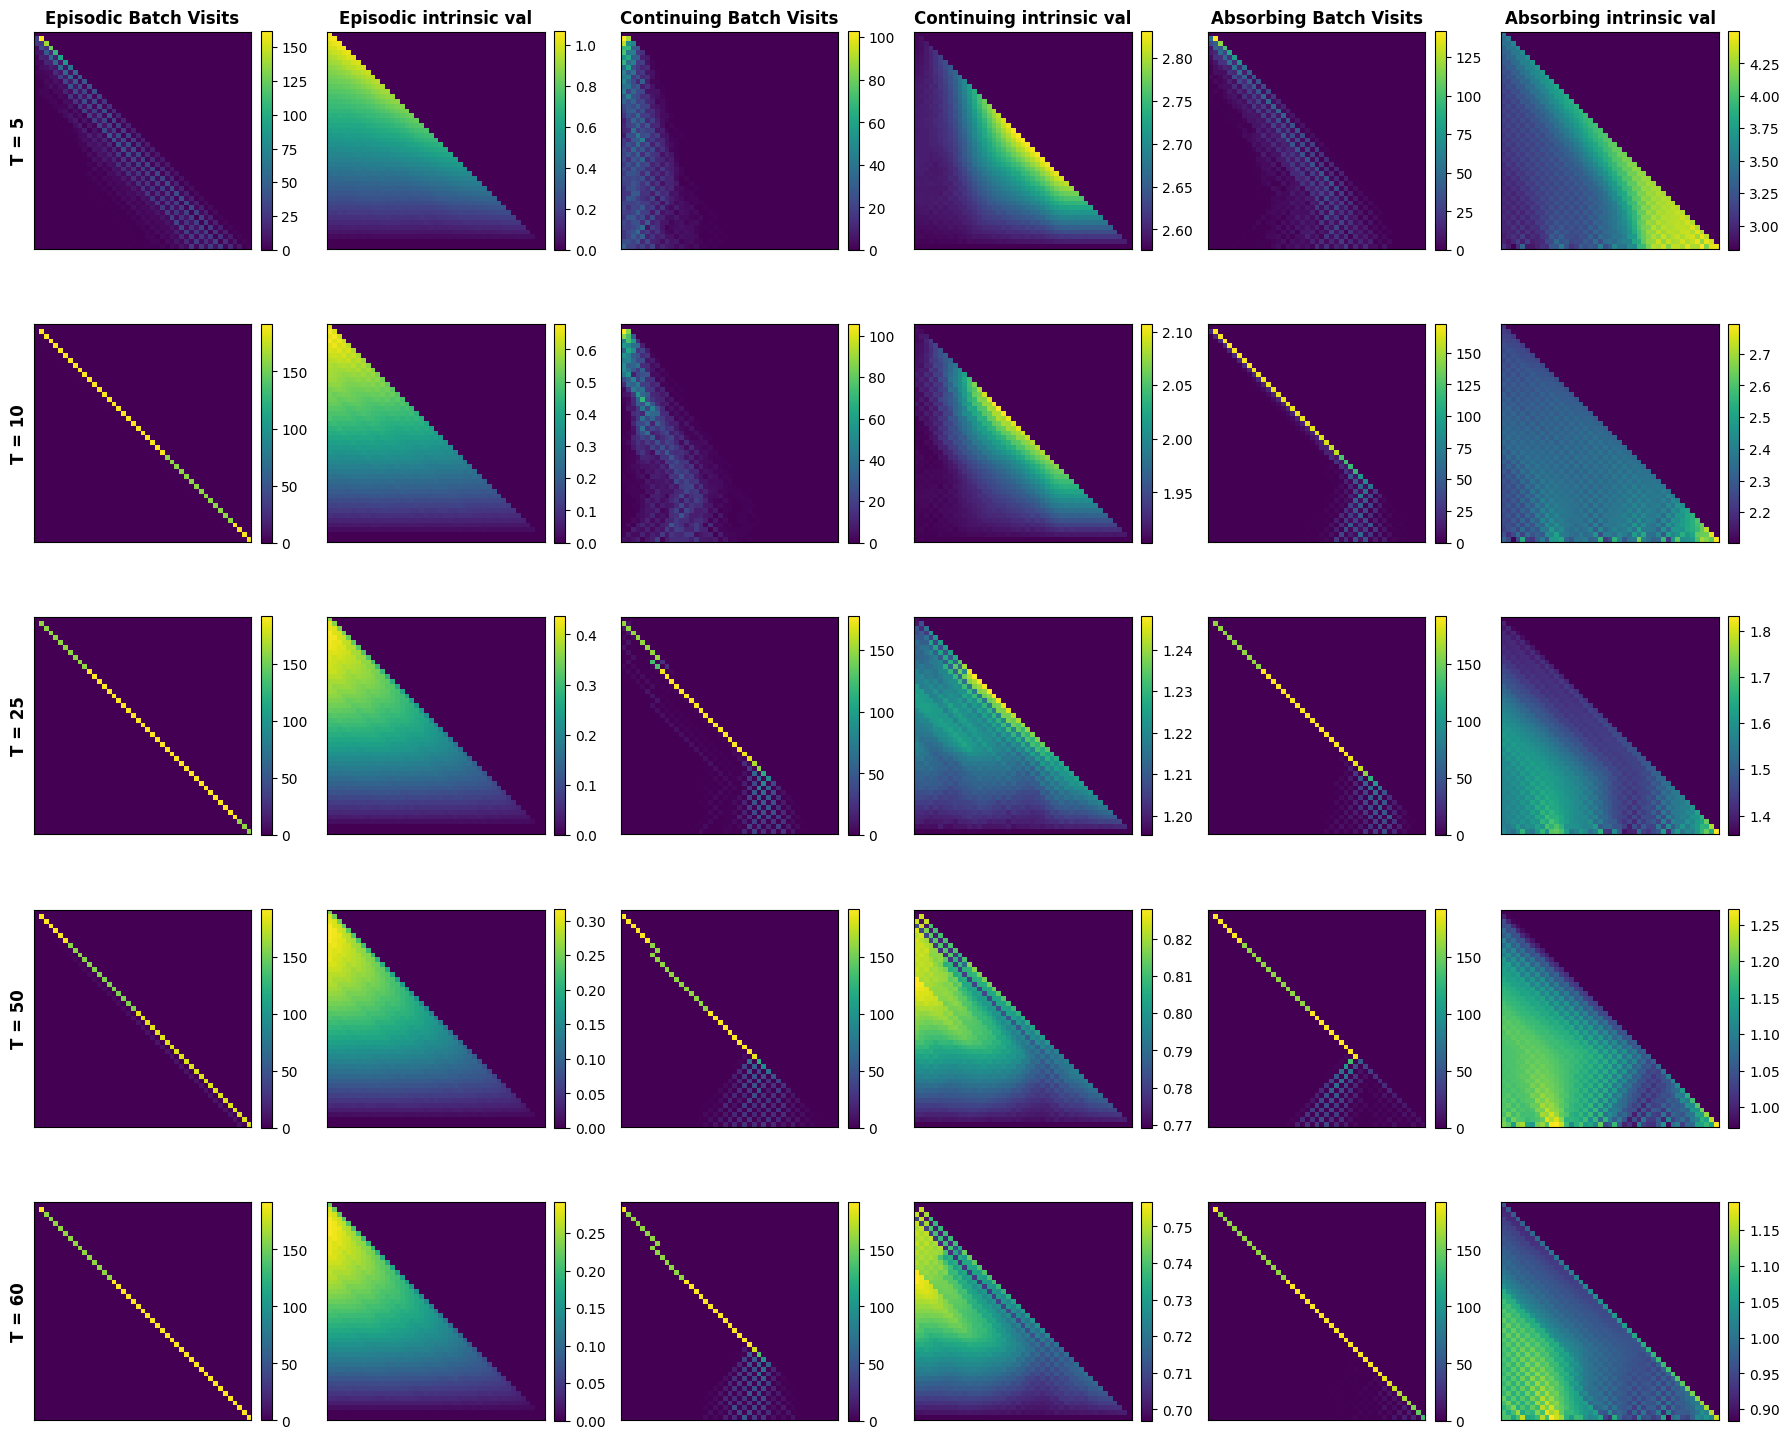

In [4]:
ep_config, ep_metrics = load_run_data("3_26_oracle/episodic_long_mem", "DeepSea-bsuite",)
cont_config, cont_metrics = load_run_data("3_26_oracle/continuing_long_mem", "DeepSea-bsuite",)
abs_config, abs_metrics = load_run_data("3_26_oracle/absorbing_long_mem", "DeepSea-bsuite",)

N = ep_config['DEEPSEA_SIZE'] 
reachable_mask = jnp.tril(jnp.ones((N, N)))

T_values = [5,10,25,50, 60]
SEED=0

# 3 variants * 2 metrics each = 6 columns
fig, axes = plt.subplots(len(T_values), 6, figsize=(18, len(T_values) * 3))

# Grouping the runs to easily iterate over the "super columns"
runs = [
    ("Episodic", ep_metrics),
    ("Continuing", cont_metrics),
    ("Absorbing", abs_metrics)
]

for row_idx, T in enumerate(T_values):
    for run_idx, (run_name, metrics) in enumerate(runs):
        # Calculate the starting column index for this specific run
        col_offset = run_idx * 2
        
        # --- Sub-column 1: Effective Visits ---
        ax_visits = axes[row_idx, col_offset]
        visits_data = metrics['visitation_count'][SEED][T] * reachable_mask
        im_visits = ax_visits.imshow(visits_data, vmin=0)
        
        if row_idx == 0:
            ax_visits.set_title(f"{run_name} Batch Visits", fontweight='bold')
            
        plt.colorbar(im_visits, ax=ax_visits, fraction=0.046, pad=0.04)
        
        # --- Sub-column 2: True v_i ---
        ax_vi = axes[row_idx, col_offset + 1]
        vi_data = metrics['v_i'][SEED][T] * reachable_mask
        im_vi = ax_vi.imshow(vi_data, vmin=metrics['v_i'][SEED][T].min())
        
        if row_idx == 0:
            ax_vi.set_title(f"{run_name} intrinsic val", fontweight='bold')
            
        plt.colorbar(im_vi, ax=ax_vi, fraction=0.046, pad=0.04)
        
        # Remove ticks for both subplots
        ax_visits.set_xticks([])
        ax_visits.set_yticks([])
        ax_vi.set_xticks([])
        ax_vi.set_yticks([])

    # Add row label (update step) to the very first column of the grid
    axes[row_idx, 0].set_ylabel(f'T = {T}', fontsize=12, fontweight='bold')

plt.tight_layout()
# plt.savefig('figures/variants_grids_over_time.pdf', bbox_inches='tight')
plt.show()

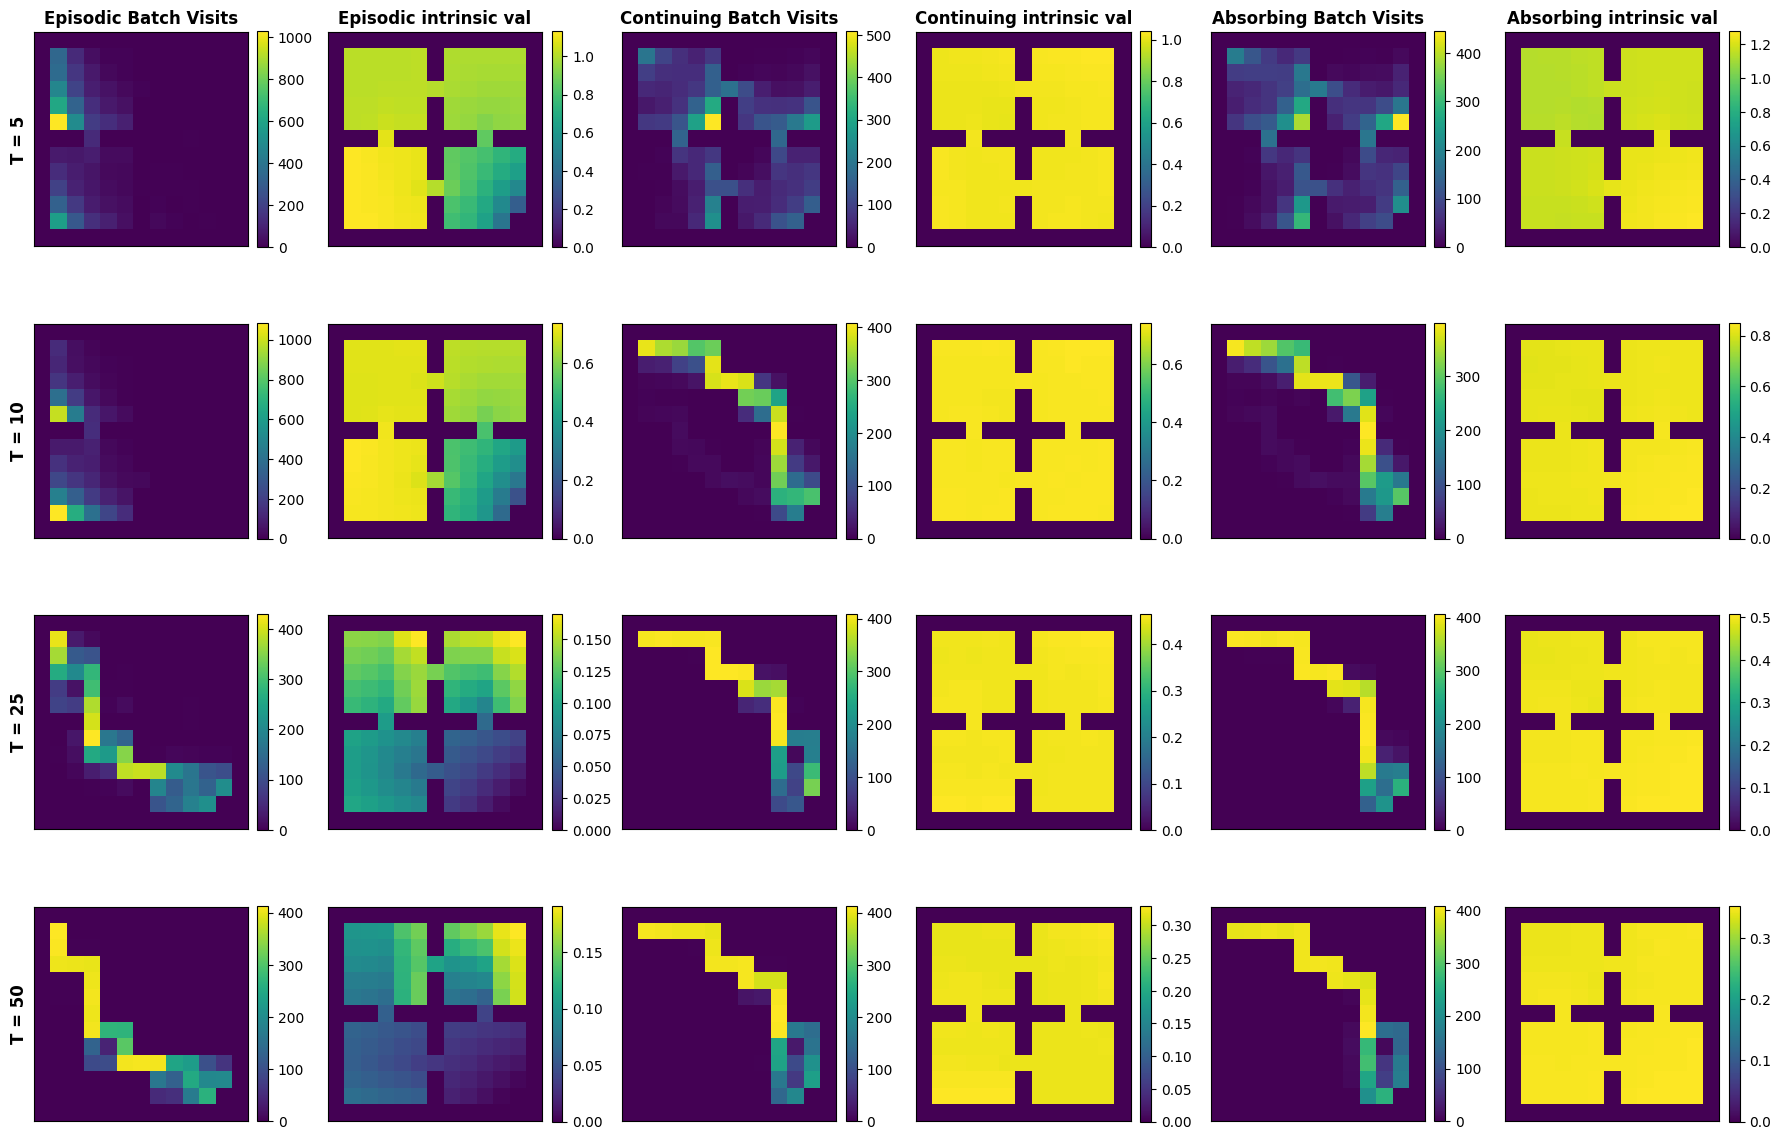

In [5]:
ep_config, ep_metrics = load_run_data("3_26_oracle/episodic_long_mem", "FourRooms-misc",)
cont_config, cont_metrics = load_run_data("3_26_oracle/continuing_long_mem", "FourRooms-misc",)
abs_config, abs_metrics = load_run_data("3_26_oracle/absorbing_long_mem", "FourRooms-misc",)


# Assuming the data is loaded as in your snippet
N = 13 
reachable_mask = jnp.ones((N, N))

T_values = [5,10,25,50]

# 3 variants * 2 metrics each = 6 columns
fig, axes = plt.subplots(len(T_values), 6, figsize=(18, len(T_values) * 3))


run_variants = {
    'Episodic vi': '3_26_oracle/episodic_long_mem',
    'Continuing vi': '3_26_oracle/continuing_long_mem',
    'Absorbing vi': '3_26_oracle/absorbing_long_mem'
}

# Grouping the runs to easily iterate over the "super columns"
runs = [
    ("Episodic", ep_metrics),
    ("Continuing", cont_metrics),
    ("Absorbing", abs_metrics)
]

for row_idx, T in enumerate(T_values):
    for run_idx, (run_name, metrics) in enumerate(runs):
        # Calculate the starting column index for this specific run
        col_offset = run_idx * 2
        
        # --- Sub-column 1: Effective Visits ---
        ax_visits = axes[row_idx, col_offset]
        visits_data = metrics['visitation_count'][0][T] * reachable_mask
        im_visits = ax_visits.imshow(visits_data, vmin=0)
        
        if row_idx == 0:
            ax_visits.set_title(f"{run_name} Batch Visits", fontweight='bold')
            
        plt.colorbar(im_visits, ax=ax_visits, fraction=0.046, pad=0.04)
        
        # --- Sub-column 2: True v_i ---
        ax_vi = axes[row_idx, col_offset + 1]
        vi_data = metrics['v_i'][0][T] * reachable_mask
        im_vi = ax_vi.imshow(vi_data, vmin=metrics['v_i'][0][T].min())
        
        if row_idx == 0:
            ax_vi.set_title(f"{run_name} intrinsic val", fontweight='bold')
            
        plt.colorbar(im_vi, ax=ax_vi, fraction=0.046, pad=0.04)
        
        # Remove ticks for both subplots
        ax_visits.set_xticks([])
        ax_visits.set_yticks([])
        ax_vi.set_xticks([])
        ax_vi.set_yticks([])

    # Add row label (update step) to the very first column of the grid
    axes[row_idx, 0].set_ylabel(f'T = {T}', fontsize=12, fontweight='bold')

plt.tight_layout()
# plt.savefig('figures/variants_grids_over_time.pdf', bbox_inches='tight')
plt.show()

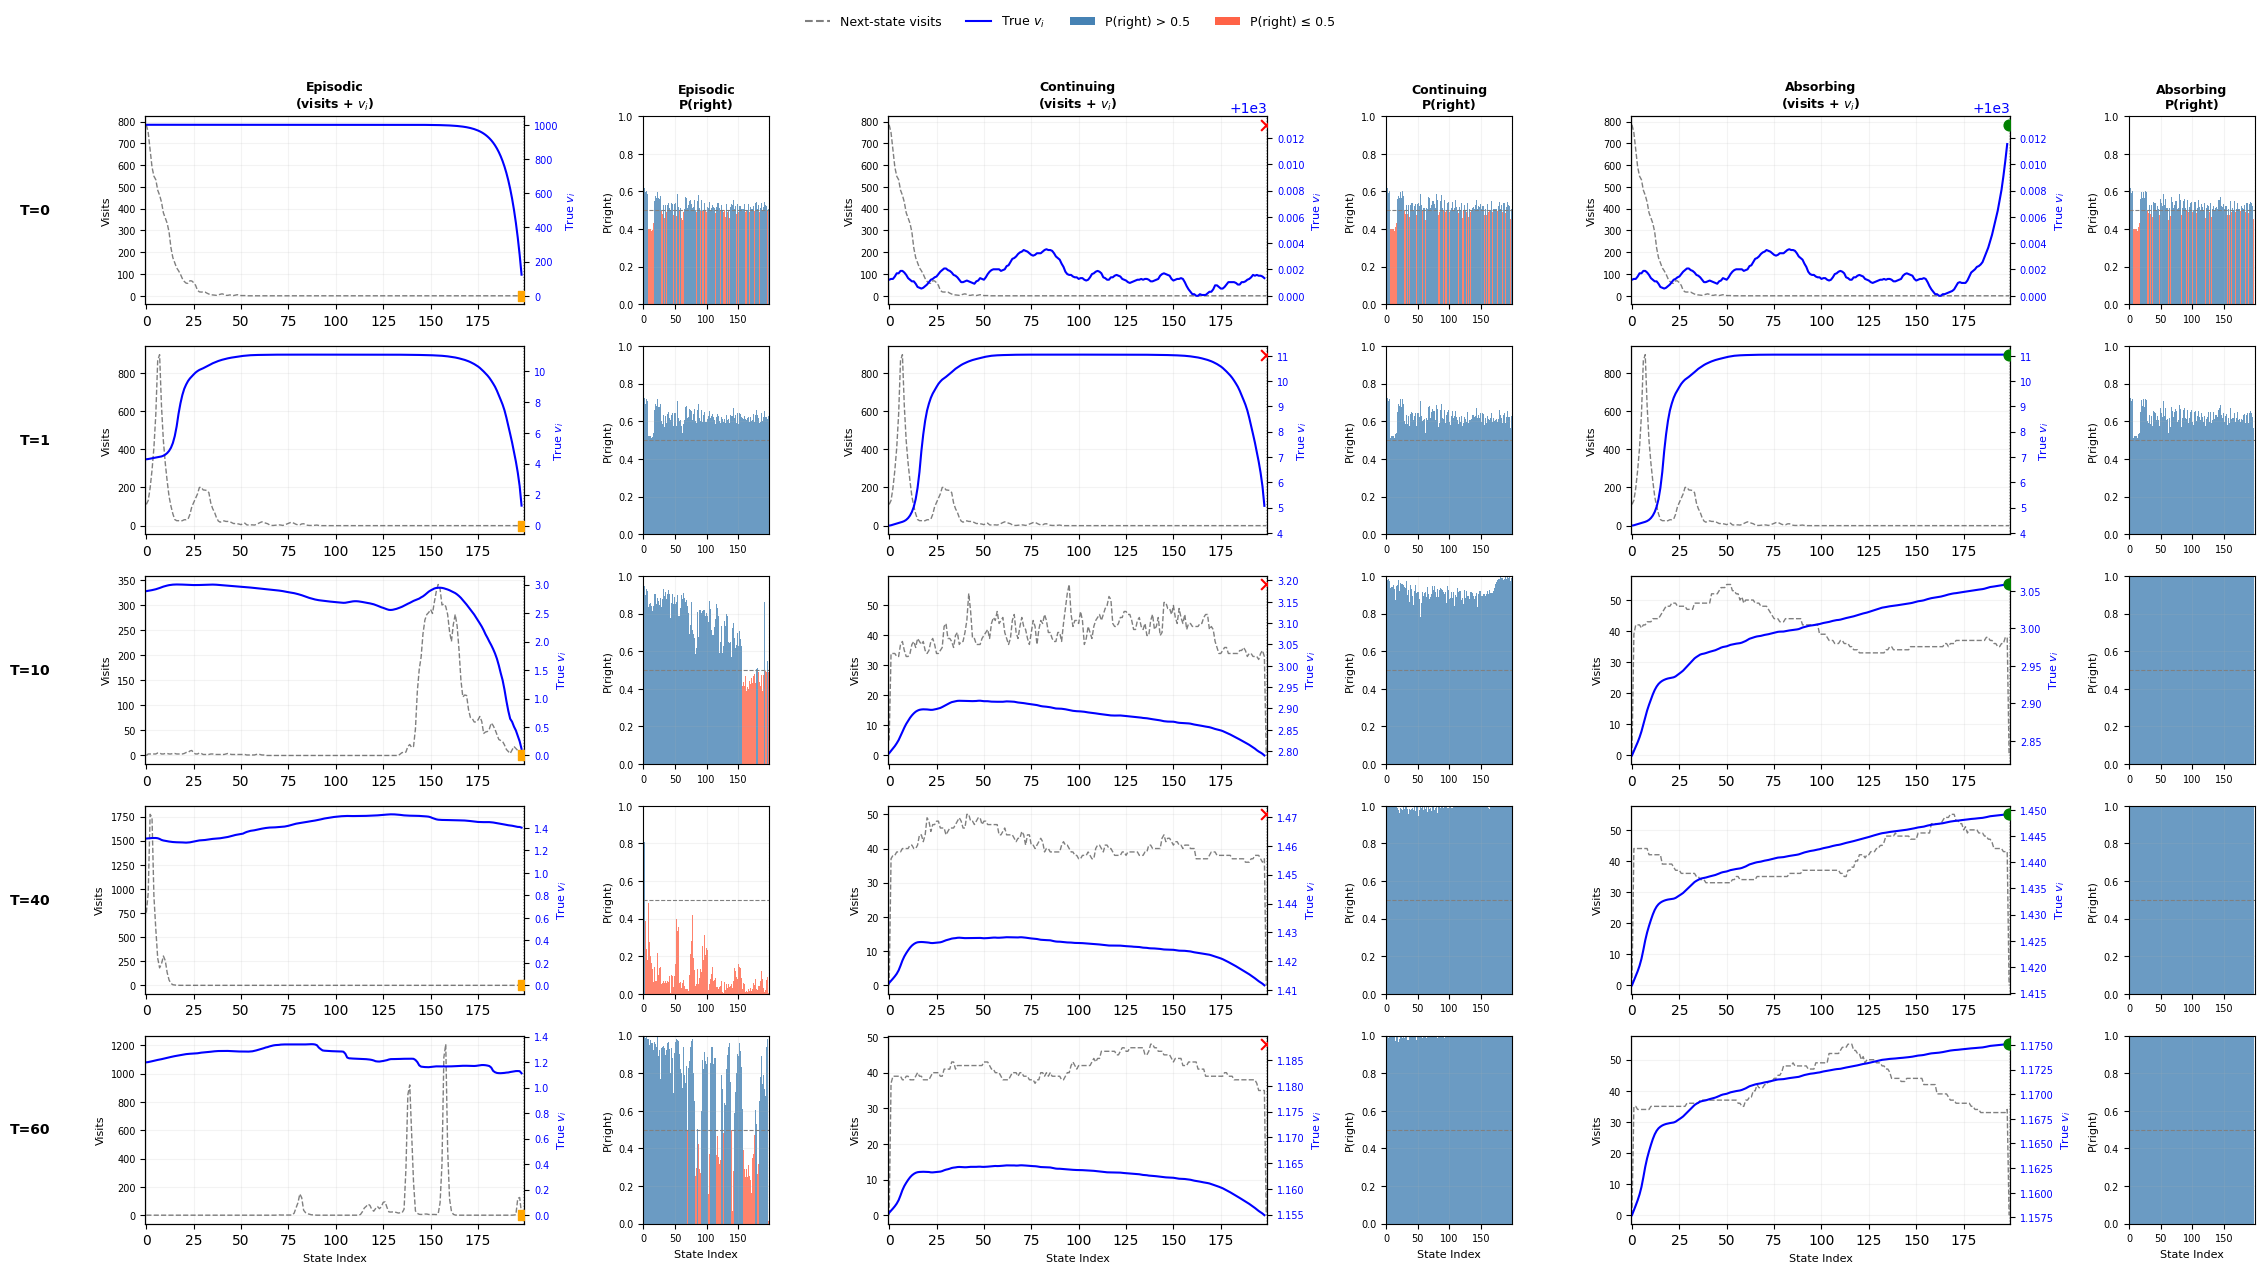

📁 Found ../figures/chain_oracle.pdf (138.2 KB)
📤 Sending to ds541@cs.duke.edu using sendmail...
✅ Email sent successfully with attachment!
📧 Check your inbox at ds541@cs.duke.edu


True

In [ ]:
import matplotlib.pyplot as plt
import jax.numpy as jnp

def plot_chain_comparison(T_values=[0, 1, 10, 40, 60], SEED=0):
    variants = [
        ("Episodic",   load_run_data("3_26_oracle/episodic_long_mem",   "Chain")),
        ("Continuing", load_run_data("3_26_oracle/continuing_long_mem", "Chain")),
        ("Absorbing",  load_run_data("3_26_oracle/absorbing_long_mem",  "Chain")),
    ]
    n_rows = len(T_values)
    n_cols = len(variants)

    # 3 columns x 3 panels each: visits+vi, policy_a1
    # Layout: for each variant we use 2 subplots wide (vi+visits | policy)
    fig, axes = plt.subplots(n_rows, n_cols * 2, figsize=(n_cols * 8, n_rows * 2.5),
                              gridspec_kw={'width_ratios': [3, 1] * n_cols})
    for row_idx, T in enumerate(T_values):
        for col_idx, (name, (config, metrics)) in enumerate(variants):
            ax_main   = axes[row_idx, col_idx * 2]
            ax_policy = axes[row_idx, col_idx * 2 + 1]

            vis = metrics['visitation_count'][SEED][T]
            vi  = metrics['v_i'][SEED][T]
            pol = metrics['policy_grid_a1'][SEED][T]

            n_states = len(vi)          # 200, the authoritative length
            terminal_idx = n_states - 1
            xs = jnp.arange(n_states)

            # Pad visitation to match v_i length if still current-obs based (length 199)
            if len(vis) < n_states:
                vis = jnp.concatenate([vis, jnp.zeros(n_states - len(vis))])
            if len(pol) < n_states:
                pol = jnp.concatenate([pol, jnp.zeros(n_states - len(pol))])

            # --- Visitation (primary axis) ---
            p_vis, = ax_main.plot(xs, vis, color='black', ls='--', lw=1.0,
                                  alpha=0.5, label='Next-state visits')
            ax_main.set_ylabel('Visits', color='black', fontsize=8)
            ax_main.tick_params(axis='y', labelcolor='black', labelsize=7)

            # --- v_i (secondary axis) ---
            ax_vi = ax_main.twinx()
            # Plot states 0..N-2 normally
            p_vi, = ax_vi.plot(xs[:-1], vi[:-1], color='blue', lw=1.5, label='True $v_i$')
            # Terminal state: marker only, style varies by formulation
            terminal_styles = {
                "Absorbing":  dict(color='green',  marker='o', label='Terminal (ghost updated)'),
                "Continuing": dict(color='red',    marker='x', label='Terminal (artifact)'),
                "Episodic":   dict(color='orange', marker='s', label='Terminal (zero value)'),
            }
            ts = terminal_styles[name]
            p_term = ax_vi.scatter([terminal_idx], [vi[terminal_idx]],
                                   zorder=5, s=60, **ts)
            ax_vi.set_ylabel('True $v_i$', color='blue', fontsize=8)
            ax_vi.tick_params(axis='y', labelcolor='blue', labelsize=7)

            # Light vertical line at terminal
            ax_main.axvline(x=terminal_idx, color='gray', ls=':', lw=0.8, alpha=0.6)

            if row_idx == 0:
                ax_main.set_title(f"{name}\n(visits + $v_i$)", fontweight='bold', fontsize=9)
            if col_idx == 0:
                ax_main.annotate(f"T={T}", xy=(-0.25, 0.5), xycoords='axes fraction',
                                 fontsize=10, fontweight='bold', ha='right', va='center')

            ax_main.set_xlim(-0.5, terminal_idx + 0.5)
            ax_main.grid(True, alpha=0.15)
            if row_idx == n_rows - 1:
                ax_main.set_xlabel('State Index', fontsize=8)

            # --- Policy: P(right) as a bar chart ---
            # Color bars by probability: blue=right-leaning, red=left-leaning
            colors = ['steelblue' if p > 0.5 else 'tomato' for p in pol]
            ax_policy.bar(xs, pol, color=colors, width=1.0, alpha=0.8)
            ax_policy.axhline(0.5, color='gray', ls='--', lw=0.8)
            ax_policy.set_ylim(0, 1)
            ax_policy.set_ylabel('P(right)', fontsize=8)
            ax_policy.tick_params(labelsize=7)
            ax_policy.set_xlim(-0.5, terminal_idx + 0.5)
            ax_policy.axvline(x=terminal_idx, color='gray', ls=':', lw=0.8, alpha=0.6)

            if row_idx == 0:
                ax_policy.set_title(f"{name}\nP(right)", fontweight='bold', fontsize=9)
            if row_idx == n_rows - 1:
                ax_policy.set_xlabel('State Index', fontsize=8)
            ax_policy.grid(True, alpha=0.15)

    # Shared legend
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch
    legend_elements = [
        Line2D([0], [0], color='black', ls='--', alpha=0.5, label='Next-state visits'),
        Line2D([0], [0], color='blue',  lw=1.5,             label='True $v_i$'),
        Patch(facecolor='steelblue', label='P(right) > 0.5'),
        Patch(facecolor='tomato',    label='P(right) ≤ 0.5'),
    ]
    fig.legend(handles=legend_elements, loc='upper center',
               bbox_to_anchor=(0.5, 1.02), ncol=4, frameon=False, fontsize=9)

    plt.tight_layout(rect=[0.05, 0, 1, 0.97])
    plt.show()
    return fig

fig = plot_chain_comparison()

fig.savefig('../figures/chain_oracle.pdf')
email_pdf('../figures/chain_oracle.pdf')

📁 Found ../figures/ds_oracle.pdf (150.9 KB)
📤 Sending to ds541@cs.duke.edu using sendmail...
✅ Email sent successfully with attachment!
📧 Check your inbox at ds541@cs.duke.edu


True

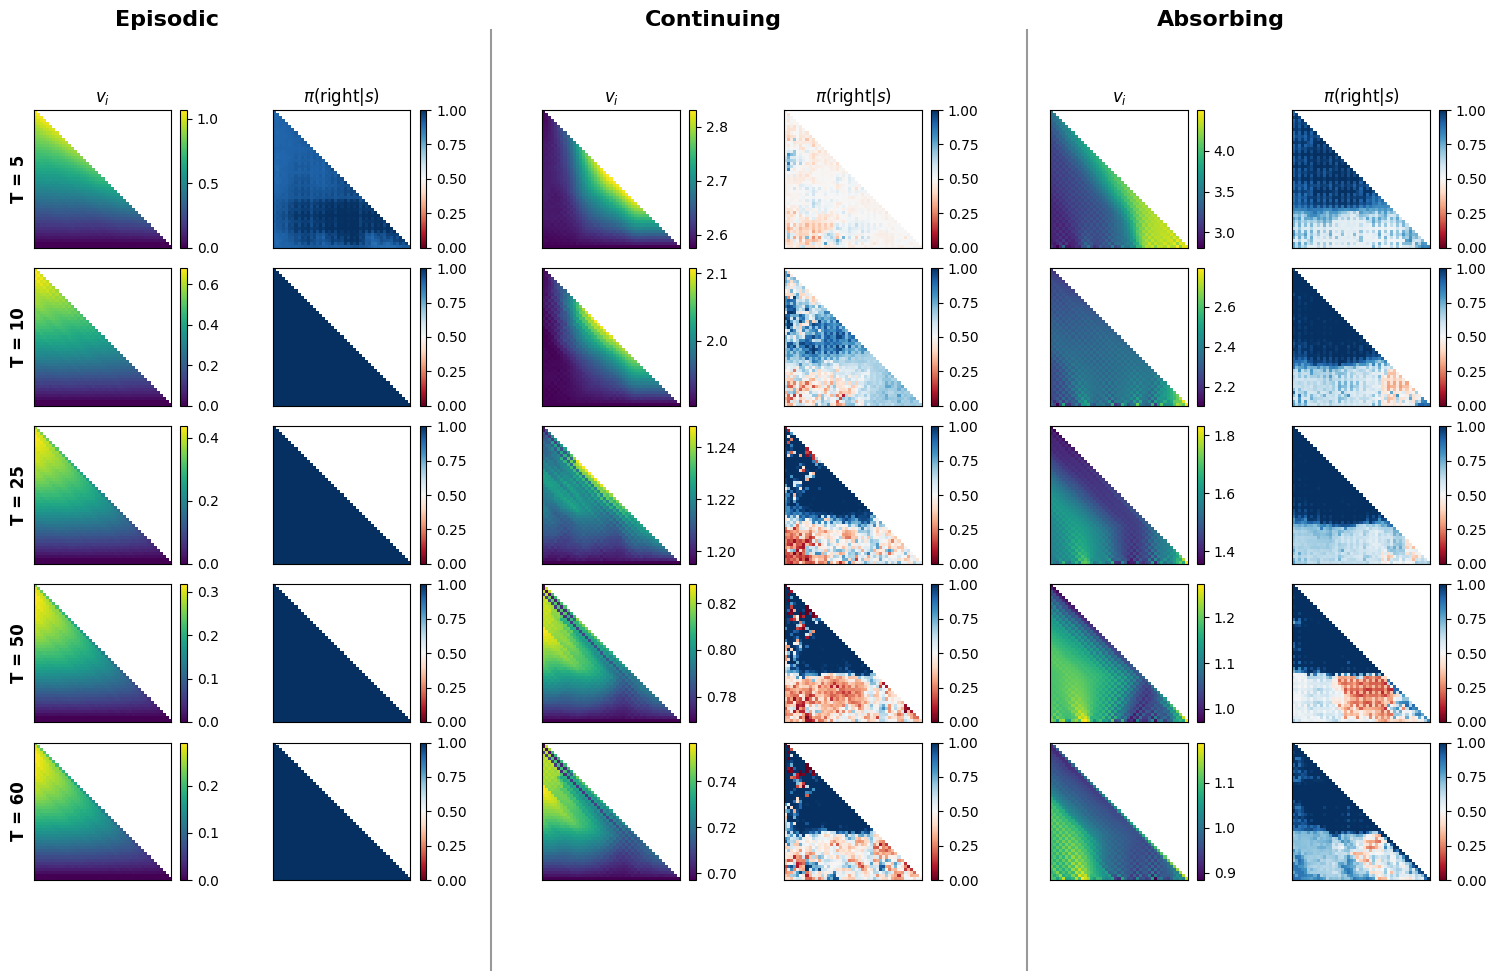

In [18]:
ep_config, ep_metrics = load_run_data("3_26_oracle/episodic_long_mem", "DeepSea-bsuite",)
cont_config, cont_metrics = load_run_data("3_26_oracle/continuing_long_mem", "DeepSea-bsuite",)
abs_config, abs_metrics = load_run_data("3_26_oracle/absorbing_long_mem", "DeepSea-bsuite",)



# Assuming ep_config, ep_metrics, etc., are already loaded
N = ep_config['DEEPSEA_SIZE']
reachable_mask = jnp.tril(jnp.ones((N, N)))
T_values = [5, 10, 25, 50, 60]
SEED = 0

runs = [
    ("Episodic",   ep_metrics),
    ("Continuing",   cont_metrics), 
    ("Absorbing",  abs_metrics),
]


fig = plt.figure(figsize=(16, len(T_values) * 2))
subfigs = fig.subfigures(1, 3, wspace=0.0, width_ratios=[1.15, 1, 1], facecolor='none')

for run_idx, (run_name, metrics) in enumerate(runs):
    subfig = subfigs[run_idx]
    subfig.suptitle(run_name, fontsize=16, fontweight='bold', y=0.98)
    
    left_margin = 0.15 if run_idx == 0 else 0.02
    gs_kw = {'wspace': 0.05, 'hspace': 0.15, 'left': left_margin, 'right': 0.95}
    axes = subfig.subplots(len(T_values), 2, gridspec_kw=gs_kw)
    
    for row_idx, T in enumerate(T_values):
        ax_vi  = axes[row_idx, 0]
        ax_pol = axes[row_idx, 1]
        
        vi_data  = jnp.where(reachable_mask, metrics['v_i'][SEED][T], jnp.nan)
        pol_data = jnp.where(reachable_mask, metrics['policy_grid_a1'][SEED][T], jnp.nan)
        
        im_vi = ax_vi.imshow(vi_data, vmin=jnp.nanmin(vi_data), cmap='viridis')
        plt.colorbar(im_vi, ax=ax_vi, fraction=0.046, pad=0.04)
        
        im_pol = ax_pol.imshow(pol_data, vmin=0, vmax=1, cmap='RdBu', interpolation='nearest')
        plt.colorbar(im_pol, ax=ax_pol, fraction=0.046, pad=0.04)
        
        for ax in (ax_vi, ax_pol):
            ax.set_xticks([]); ax.set_yticks([])
            
        if row_idx == 0:
            ax_vi.set_title(r"$v_i$", fontsize=12)
            ax_pol.set_title(r"$\pi(\mathrm{right}|s)$", fontsize=12)
        if run_idx == 0:
            ax_vi.set_ylabel(f'T = {T}', fontsize=12, fontweight='bold')

# --- MOVED OUTSIDE ALL LOOPS ---

# 3. Draw vertical lines dividing the super columns
# We use fig.add_artist with transFigure now that subfigs are transparent
for x in [0.385, 0.72]:
    line = plt.Line2D(
        [x, x], [0.02, 0.96], 
        transform=fig.transFigure, 
        color='black', 
        linewidth=1.5, 
        alpha=0.4, 
        zorder=100
    )
    fig.add_artist(line)

fig.savefig('../figures/ds_oracle.pdf')
email_pdf('../figures/ds_oracle.pdf')